<a href="https://colab.research.google.com/github/azizajamjoom/CA04---Ensemble_Models/blob/main/CA04_Ensemble_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data Source and Contents

In [2]:
import pandas as pd
import numpy as np
#For encoding the categorical variables
from sklearn.preprocessing import OrdinalEncoder
#For Visualizations
import matplotlib.pyplot as plt
#For Ensemble Models
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

In [3]:
df = pd.read_csv("https://github.com/ArinB/MSBA-CA-03-Decision-Trees/blob/master/census_data.csv?raw=true")
df

,hours_per_week_bin,occupation_bin,msr_bin,capital_gl_bin,race_sex_bin,education_num_bin,education_bin,workclass_bin,age_bin,flag,y
0,b. 31-40,b. Mid - Low,b. Mid,c. > 0,c. High,c. 13,c. Bachelors,b. income,d. 36-40 & 56-60,train,0
1,a. 0-30,e. High,c. High,a. = 0,c. High,c. 13,c. Bachelors,b. income,e. 40-55,train,0
2,b. 31-40,a. Low,b. Mid,a. = 0,c. High,b. 9-12,b. Mid,b. income,d. 36-40 & 56-60,train,0
3,b. 31-40,a. Low,c. High,a. = 0,b. Mid,a. 0-8,a. Low,b. income,e. 40-55,train,0
4,b. 31-40,e. High,c. High,a. = 0,a. Low,c. 13,c. Bachelors,b. income,b. 26-30 & 71-100,train,0
...,...,...,...,...,...,...,...,...,...,...,...
48837,b. 31-40,e. High,b. Mid,a. = 0,b. Mid,c. 13,c. Bachelors,b. income,d. 36-40 & 56-60,test,0
48838,b. 31-40,b. Mid - Low,a. Low,a. = 0,b. Mid,b. 9-12,b. Mid,a. no income,c. 31-35 & 61-70,test,0
48839,d. 41-50 & 61-70,e. High,c. High,a. = 0,c. High,c. 13,c. Bachelors,b. income,d. 36-40 & 56-60,test,0
48840,b. 31-40,b. Mid - Low,a. Low,c. > 0,c. High,c. 13,c. Bachelors,b. income,e. 40-55,test,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   hours_per_week_bin  48842 non-null  object
 1   occupation_bin      48842 non-null  object
 2   msr_bin             48842 non-null  object
 3   capital_gl_bin      48842 non-null  object
 4   race_sex_bin        48842 non-null  object
 5   education_num_bin   48842 non-null  object
 6   education_bin       48842 non-null  object
 7   workclass_bin       48842 non-null  object
 8   age_bin             48842 non-null  object
 9   flag                48842 non-null  object
 10  y                   48842 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 4.1+ MB


### Encoding Categorical Variables

In [5]:
#Creating a List of Categorical Variables
cat_vars = df.dtypes[df.dtypes == "object"].index
cat_vars = cat_vars.to_list()
cat_vars.remove('flag')
cat_vars

['hours_per_week_bin',
 'occupation_bin',
 'msr_bin',
 'capital_gl_bin',
 'race_sex_bin',
 'education_num_bin',
 'education_bin',
 'workclass_bin',
 'age_bin']

In [6]:
#Checking the order of the columns and their bins in cat_vars
for col in cat_vars:
    print(f"\nColumn: {col}")
    print(list(df[col].dropna().unique()))


Column: hours_per_week_bin
['b. 31-40', 'a. 0-30', 'd. 41-50 & 61-70', 'c. 71-100', 'e. 51-60']

Column: occupation_bin
['b. Mid - Low', 'e. High', 'a. Low', 'c. Mid - Mid', 'd. Mid - High']

Column: msr_bin
['b. Mid', 'c. High', 'a. Low']

Column: capital_gl_bin
['c. > 0', 'a. = 0', 'b. < 0']

Column: race_sex_bin
['c. High', 'b. Mid', 'a. Low']

Column: education_num_bin
['c. 13', 'b. 9-12', 'a. 0-8', 'd. 14', 'e. 15+']

Column: education_bin
['c. Bachelors', 'b. Mid', 'a. Low', 'd. Masters', 'e. High']

Column: workclass_bin
['b. income', 'a. no income']

Column: age_bin
['d. 36-40 & 56-60', 'e. 40-55', 'b. 26-30 & 71-100', 'c. 31-35 & 61-70', 'a. 0-25']


In [7]:
# Logically ordering the categories (low → high) for each column:

cat_vars = ['hours_per_week_bin','occupation_bin','msr_bin','capital_gl_bin',
            'race_sex_bin','education_num_bin','education_bin','workclass_bin','age_bin']

categories = [
    # hours_per_week_bin
    ["a. 0-30", "b. 31-40", "d. 41-50 & 61-70", "e. 51-60", "c. 71-100"],

    # occupation_bin
    ["a. Low", "b. Mid - Low","c. Mid - Mid","d. Mid - High","e. High"],

    # msr_bin (Marriage Status & Relationships)
    ["a. Low","b. Mid","c. High"],

    # capital_gl_bin (financial logic: loss < zero < gain)
    ["b. < 0", "a. = 0","c. > 0"],

    # race_sex_bin
    ["a. Low","b. Mid","c. High"],

    # education_num_bin (increasing years)
    ["a. 0-8","b. 9-12","c. 13","d. 14","e. 15+"],

    # education_bin (increasing attainment)
    ["a. Low","b. Mid","c. Bachelors","d. Masters","e. High"],

    # workclass_bin
    ["a. no income","b. income"],

    # age_bin (progression by approximate age)
    ["a. 0-25","b. 26-30 & 71-100","c. 31-35 & 61-70","d. 36-40 & 56-60","e. 40-55"]
]

In [8]:
# Building the Encoder
encoder = OrdinalEncoder(
    categories=categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1)

# Fitting the encoder on the full dataset
df_for_fit = df.copy()
for c in cat_vars:
    df_for_fit[c] = df_for_fit[c].astype(str)

encoder.fit(df_for_fit[cat_vars])

# Creating a new encoded copy and keep the original df unchanged
df_encoded = df.copy()
for c in cat_vars:
    df_encoded[c] = df_encoded[c].astype(str)

df_encoded[cat_vars] = encoder.transform(df_encoded[cat_vars])

df_encoded

,hours_per_week_bin,occupation_bin,msr_bin,capital_gl_bin,race_sex_bin,education_num_bin,education_bin,workclass_bin,age_bin,flag,y
0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,3.0,train,0
1,0.0,4.0,2.0,1.0,2.0,2.0,2.0,1.0,4.0,train,0
2,1.0,0.0,1.0,1.0,2.0,1.0,1.0,1.0,3.0,train,0
3,1.0,0.0,2.0,1.0,1.0,0.0,0.0,1.0,4.0,train,0
4,1.0,4.0,2.0,1.0,0.0,2.0,2.0,1.0,1.0,train,0
...,...,...,...,...,...,...,...,...,...,...,...
48837,1.0,4.0,1.0,1.0,1.0,2.0,2.0,1.0,3.0,test,0
48838,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,2.0,test,0
48839,2.0,4.0,2.0,1.0,2.0,2.0,2.0,1.0,3.0,test,0
48840,1.0,1.0,0.0,2.0,2.0,2.0,2.0,1.0,4.0,test,0


### Splitting Training and Testing Data

In [9]:
train = df_encoded[df_encoded['flag'] == 'train']
test = df_encoded[df_encoded['flag'] == 'test']

In [10]:
##### Might Delete ; Copied from CA03

x_train = train.drop(columns=['y', 'flag'])
y_train = train['y']

x_test  = test.drop(columns=['y', 'flag'])
y_test  = test['y']

# 3. Building a Random Forest Model

In [11]:
#Creating the list of the number of estimators we want to us
n_estimators = [50,100,150,200,250,300,350,400,450,500]

#Creating empty lists that the for loop will append with the accruacy scores and AUC scores
accuracy_list = []
auc_list = []

#Random Forest Model
for trees in n_estimators:
  model = RandomForestClassifier(n_estimators = trees, random_state = 101)
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)

  #Calculatng Accuracy Score and Appending to the List
  accuracy = np.mean(y_test == y_pred)
  accuracy_list.append(accuracy)

  #Calculating AUC Score and Appending to the List
  y_pred_prob = model.predict_proba(x_test)[ : ,1]
  auc_score = roc_auc_score(y_test, y_pred_prob)
  auc_list.append(auc_score)

print(f'Accuracy: {accuracy_list}')
print(f'AUC: {auc_list}')

Accuracy: [np.float64(0.8384620109329893), np.float64(0.8382163257785148), np.float64(0.8382777470671334), np.float64(0.837847798046803), np.float64(0.8368036361402862), np.float64(0.8376021128923284), np.float64(0.8372335851606166), np.float64(0.8375406916037098), np.float64(0.8379092193354216), np.float64(0.8382777470671334)]
AUC: [np.float64(0.8797935431691495), np.float64(0.8805351530506738), np.float64(0.8807760416568653), np.float64(0.8810604639706296), np.float64(0.8811060886343777), np.float64(0.8812690682134724), np.float64(0.8813134173939534), np.float64(0.8814646980732466), np.float64(0.8814278136063118), np.float64(0.8814374006403762)]


<Axes: >

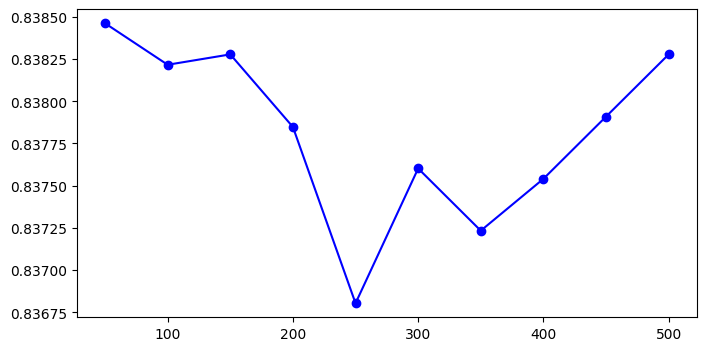

In [12]:
#Plotting Accuracy vs n_estimators
plt.figure(figsize=(8,4))
pd.Series(accuracy_list, n_estimators).plot(color = 'blue', marker = 'o')


<Axes: >

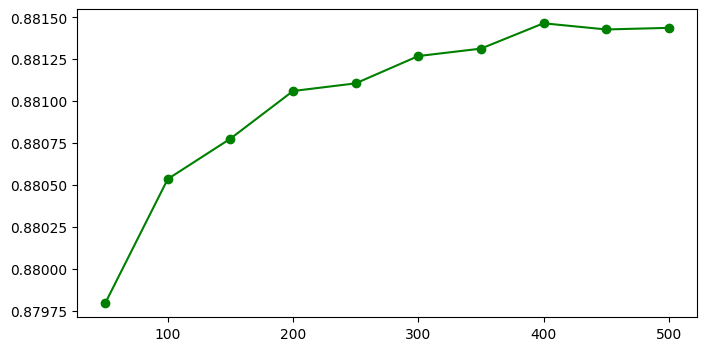

In [13]:
#Plotting AUC vs n_estimators
plt.figure(figsize=(8,4))
pd.Series(auc_list, n_estimators).plot(color = 'green', marker = 'o')


#### **Q1**: Write your observations about the Classifier’s behavior with respect to the number of estimators
**Accuracy**: Overall, accuracy of the Random Forest Model is good, as all estimator values have an accuracy between 83.68% and 83.85%. In the grand scheme of things, the range of the model's accuracy range differs only by 0.17%, which isn't bad! However, within that range, the accuracy fluctuates and is slightly unstable between 150-350 estimators. Accuracy starts high up until 150 estimators, and then begins to decline around 150-200 estimators, and then has its largest drop at 200-250 estimators. From 250-300 estimators, accuracy begins to increase again, with a slight decrease between 300-350 estimators. From 350-500 estimators, the model's accruacy steadily increases, and at 500 estimators, the model is back at the higher end of its accruacy scores, at 83.83%.


**AUC**: The AUC scores range between 87.98% and 88.14%, differing by 0.16%. As the number of estimators increase, the AUC score increases. There's a slight plateau after 400 estimators, but these AUC values are the highest of all estimators. This shows that the AUC score benefits from adding more estimators.

#### **Q2**: Is there an optimal value of the estimator within the given range?

**Accuracy**: Accuracy stands out the best at 50-150 estimators, as well as 500 estimators. Thus, those are the most optimal number of estimators for the model.

**AUC**: AUC has the best values at 400-500 estimators, with it's highest value at 500 estimators. Thus, the optimal number of estimators within our range for AUC is 500.

# 4. Building AdaBoost, Gradient Boost, and XGB.

### AdaBoost

In [14]:
#Creating the list of the number of estimators we want to us
n_estimators = [50,100,150,200,250,300,350,400,450,500]

#Creating empty lists that the for loop will append with the accruacy scores and AUC scores
ada_accuracy_list = []
ada_auc_list = []

#Random Forest Model
for trees in n_estimators:
  ada_model = AdaBoostClassifier(n_estimators = trees, random_state = 101)
  ada_model.fit(x_train, y_train)
  ada_y_pred = ada_model.predict(x_test)

  #Calculatng Accuracy Score and Appending to the List
  ada_accuracy = np.mean(y_test == ada_y_pred)
  ada_accuracy_list.append(ada_accuracy)

  #Calculating AUC Score and Appending to the List
  ada_y_pred_prob = ada_model.predict_proba(x_test)[ : ,1]
  ada_auc_score = roc_auc_score(y_test, y_pred_prob)
  ada_auc_list.append(ada_auc_score)

print(f'Accuracy: {ada_accuracy_list}')
print(f'AUC: {ada_auc_list}')

Accuracy: [np.float64(0.839199066396413), np.float64(0.8422087095387262), np.float64(0.8446655610834716), np.float64(0.8449726675265647), np.float64(0.8449112462379461), np.float64(0.8448498249493275), np.float64(0.8449112462379461), np.float64(0.8449112462379461), np.float64(0.8447884036607088), np.float64(0.8447884036607088)]
AUC: [np.float64(0.8814374006403762), np.float64(0.8814374006403762), np.float64(0.8814374006403762), np.float64(0.8814374006403762), np.float64(0.8814374006403762), np.float64(0.8814374006403762), np.float64(0.8814374006403762), np.float64(0.8814374006403762), np.float64(0.8814374006403762), np.float64(0.8814374006403762)]


<Axes: >

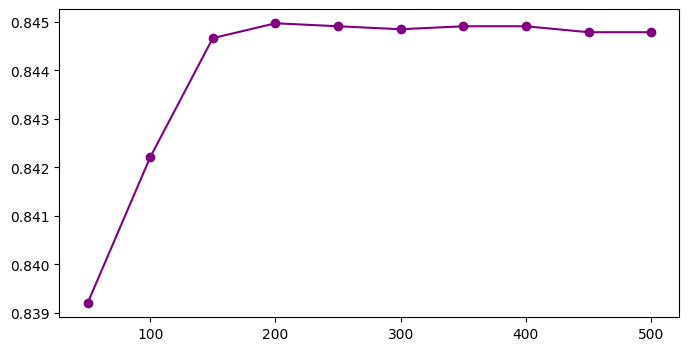

In [15]:
#Plotting Accuracy vs n_estimators
plt.figure(figsize=(8,4))
pd.Series(ada_accuracy_list, n_estimators).plot(color = 'purple', marker = 'o')


<Axes: >

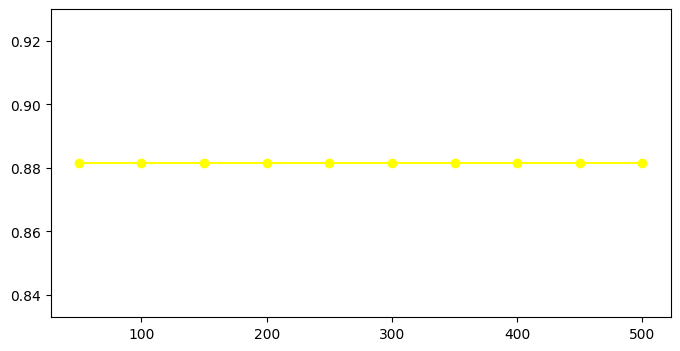

In [16]:
#Plotting AUC vs n_estimators
plt.figure(figsize=(8,4))
pd.Series(ada_auc_list, n_estimators).plot(color = 'yellow', marker = 'o')


####**Q1**: Write your observations about the Classifier’s behavior with respect to the number of estimators
**Accuracy**: The accuracy of the AdaBoost Model ranges between 83.92% and 84.50%, differing by 0.58%. As the number of estimators increase, the accuracy score increases and has no dips. After 150 estimators, the model's accuracy plateaus at the higher end of the accuracy range, with the highest accuracy being at 200 estimators.


**AUC**: For all estimators, the AUC score is flat at 88.14%. Hence, the number of estimators has no substantial effect on the model's AUC.

#### **Q2**: Is there an optimal value of the estimator within the given range?

**Accuracy**: Accuracy stands out the best after 150 estimators, with its highest accuracy value at 200 estimators. Thus, the optimal value of estimators for accuracy within our range is 200.

**AUC**: AUC stays the same for all estimator values, thus there is no unique optimal value.  


### Gradient Boost

In [17]:
### Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# Creating estimator list
n_estimators = [50,100,150,200,250,300,350,400,450,500]

# Empty result lists
gb_accuracy_list = []
gb_auc_list = []

# Loop through estimators
for n in n_estimators:

    model = GradientBoostingClassifier(
        n_estimators=n,
        random_state=101
    )

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    gb_accuracy_list.append(accuracy)
    gb_auc_list.append(auc)

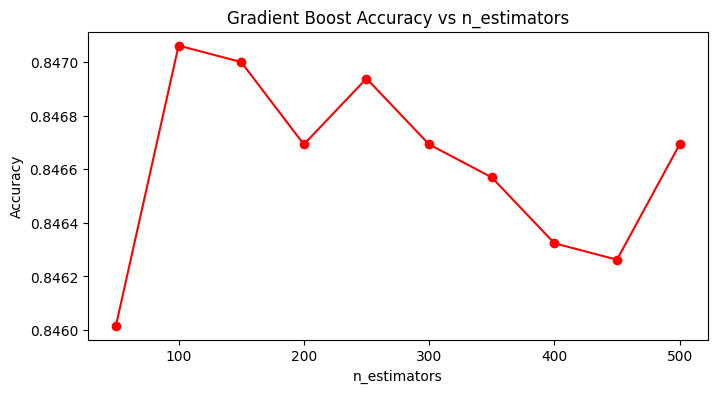

In [18]:
#Plot Accuracy
plt.figure(figsize=(8,4))
pd.Series(gb_accuracy_list, n_estimators).plot(color='red', marker='o')
plt.title("Gradient Boost Accuracy vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.show()

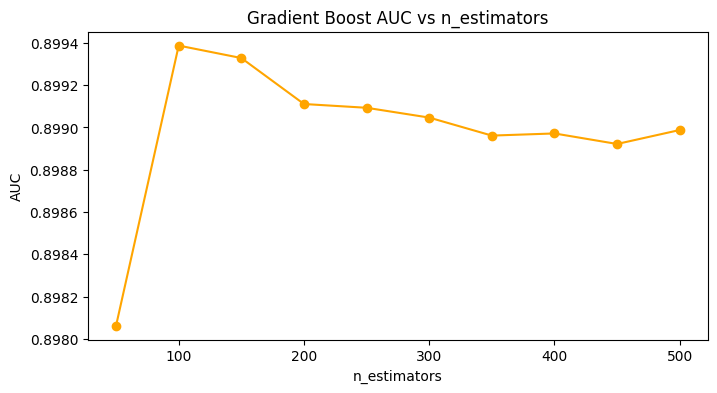

In [19]:
#Plot AUC
plt.figure(figsize=(8,4))
pd.Series(gb_auc_list, n_estimators).plot(color='orange', marker='o')
plt.title("Gradient Boost AUC vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("AUC")
plt.show()

####**Q1**: Write your observations about the Classifier’s behavior with respect to the number of estimators
**Accuracy:**
The Gradient Boosting classifier shows a rapid improvement in accuracy when increasing the number of estimators from 50 to around 100. After this point, accuracy stabilizes and fluctuates only slightly, indicating that adding more estimators provides diminishing performance gains. The model maintains consistently high accuracy across the remaining estimator values, suggesting stable learning and low variance.

AUC:
A similar pattern is observed for AUC, where performance increases sharply at lower estimator values and reaches its peak early. Beyond approximately 100 estimators, AUC values remain nearly constant with very small variations, showing that the classifier has already captured most of the predictive patterns in the data.

#### **Q2**: Is there an optimal value of the estimator within the given range?

Yes, an optimal estimator value exists within the tested range. Both Accuracy and AUC reach their highest values around 100 estimators, after which performance plateaus and slightly declines. Therefore, using approximately 100 estimators provides the best balance between model performance and computational efficiency.

### XGBoost

In [20]:
from xgboost import XGBClassifier

In [21]:
### XGBoost

n_estimators = [50,100,150,200,250,300,350,400,450,500]

xgb_accuracy_list = []
xgb_auc_list = []

for n in n_estimators:

    model = XGBClassifier(
        n_estimators=n,
        random_state=101,
        use_label_encoder=False,
        eval_metric='logloss'
    )

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    xgb_accuracy_list.append(accuracy)
    xgb_auc_list.append(auc)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:50:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:50:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:50:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:50:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

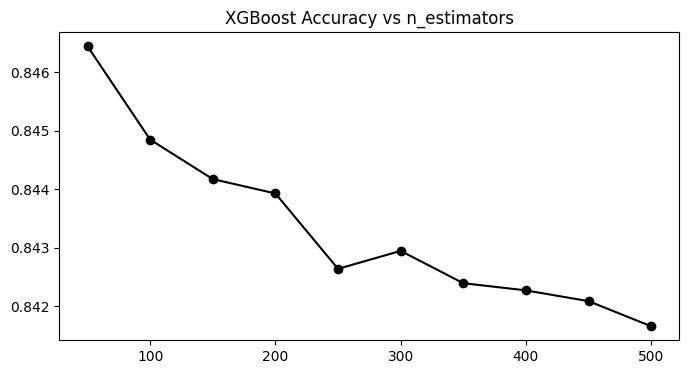

In [22]:
#Plot Accuracy
plt.figure(figsize=(8,4))
pd.Series(xgb_accuracy_list, n_estimators).plot(color='black', marker='o')
plt.title("XGBoost Accuracy vs n_estimators")
plt.show()

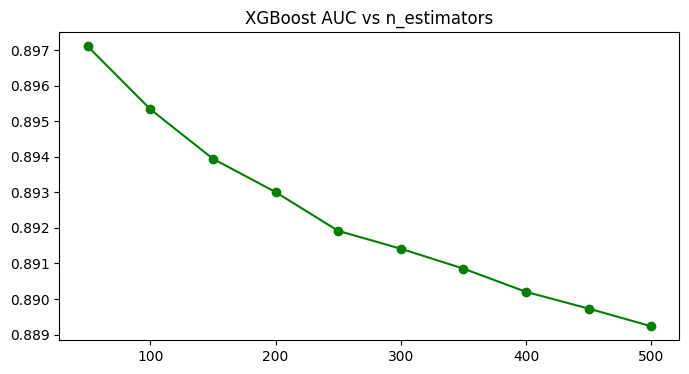

In [23]:
#Plot AUC
plt.figure(figsize=(8,4))
pd.Series(xgb_auc_list, n_estimators).plot(color='green', marker='o')
plt.title("XGBoost AUC vs n_estimators")
plt.show()

####**Q1**: Write your observations about the Classifier’s behavior with respect to the number of estimators

Accuracy and AUC are highest at lower estimator values and gradually decrease as the number of estimators increases. This shows that XGBoost learns the main patterns early, and adding more estimators does not improve performance and may slightly reduce it.

#### **Q2**: Is there an optimal value of the estimator within the given range?

Yes. The optimal value is 50 estimators, where both Accuracy and AUC reach their highest performance before declining.

# 5. Compare Performance

In [24]:
comparison_table = pd.DataFrame({
    "Metric": ["Accuracy", "AUC"],

    "Random Forest": [
        max(accuracy_list),
        max(auc_list)
    ],

    "AdaBoost": [
        max(ada_accuracy_list),
        max(ada_auc_list)
    ],

    "Gradient Boost": [
        max(gb_accuracy_list),
        max(gb_auc_list)
    ],

    "XGB": [
        max(xgb_accuracy_list),
        max(xgb_auc_list)
    ]
})

comparison_table

,Metric,Random Forest,AdaBoost,Gradient Boost,XGB
0,Accuracy,0.838462,0.844973,0.847061,0.846447
1,AUC,0.881465,0.881437,0.899387,0.897109


Among the four ensemble models, Gradient Boost achieved the highest overall performance, producing both the highest Accuracy (0.8471) and AUC (0.8994). XGBoost performed slightly lower but still showed strong predictive ability. AdaBoost provided moderate improvement over Random Forest, while Random Forest had the lowest performance among the models. Overall, boosting methods outperformed bagging, indicating that sequential error correction improved model prediction quality for this dataset.